# RPG development part 2: inventory, battles, and the full game
* this is it - the capstone of the whole game development arc, and the very last lesson of this course!
* lesson 31 built the "explore the world" half of a small RPG: a tile-grid world, a `Player` with grid-based movement and wall collision, NPC classes, and a dialogue text-box overlay
* this lesson adds the other half every RPG needs: items you can carry, a turn-based battle system, and then we tie EVERYTHING together into one short but complete, scripted RPG playthrough - start to finish
* just like lesson 18 was the capstone of the core course, this notebook is intentionally small and self-contained - we rebuild a tiny version of lesson 31's world ourselves rather than importing it, so this notebook runs completely on its own

## setup (recap lesson 27)
* same headless pygame trick as every lesson in this arc: the dummy video/audio drivers, `pygame.init()`, and our `show_surface()` helper to render a pygame `Surface` inline in the notebook
* we also fix the random seed right away - we use randomness for small damage variance in our battle system later, and a fixed seed means everyone who runs this notebook gets the EXACT same battle, every time (reproducible, no surprises)

In [1]:
import os

# these two MUST be set before "import pygame" - same headless setup as every lesson in this arc (recap lesson 27)
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render off-screen, no real display needed
os.environ["SDL_AUDIODRIVER"] = "dummy"   # no real sound device needed

import pygame
import numpy as np
import matplotlib.pyplot as plt
import random  # for a small amount of damage variance in our battle system, with a fixed seed below

pygame.init()
pygame.font.init()  # we use pygame.font for both the dialogue box (recap lesson 31 ideas) and the battle screen


def show_surface(surface, title=None, figsize=(5, 4)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


random.seed(42)  # fixed seed - every random.randint() call below becomes fully reproducible, run after run

screen = pygame.display.set_mode((320, 240))  # one shared "screen" surface, reused for the world AND the battles
font = pygame.font.SysFont(None, 18)  # a small built-in font, used for hp numbers, dialogue text and battle messages

print("pygame ready, screen is", screen.get_size(), "- lets build the rest of our RPG")

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame ready, screen is (320, 240) - lets build the rest of our RPG


## items and inventory (recap dataclasses, lesson 10)
* an `Item` is the perfect fit for `@dataclass`: it just holds data, no interesting behaviour of its own
* `item_type` tells us how to apply it: a `"potion"` heals and then gets used up (removed from the inventory), a `"weapon"` permanently boosts `attack` and STAYS in the inventory once equipped
* the `Inventory` class remembers which character it belongs to (`owner`), so `use_item()` always knows who to apply the effect to - we build the actual `Character`/`Player` classes right after this, `Inventory` just needs SOME object with `.name`/`.hp`/`.max_hp`/`.attack` attributes, it doesnt care which exact class that is

In [2]:
from dataclasses import dataclass


@dataclass
class Item:
    """A single item our player can carry. Just a plain data record, all the actual EFFECT logic lives in Inventory."""
    name: str            # display name, e.g. "Minor Potion"
    item_type: str        # "potion" (consumed on use) or "weapon" (equipped permanently) - keeps this lesson simple
    attack_bonus: int = 0  # how much attack a weapon adds when equipped (0 for non-weapons)
    heal_amount: int = 0   # how much hp a potion restores when drunk (0 for non-potions)


class Inventory:
    """A list of Items belonging to one character, plus the logic for adding items and using them."""

    def __init__(self, owner):
        self.owner = owner   # whoever this inventory belongs to - use_item() applies effects to THIS character
        self.items: list[Item] = []  # start empty, filled up via add_item() (recap list[Item] typing, lesson 10)

    def add_item(self, item: Item) -> str:
        """Add an item to the inventory (found on the ground, given by an NPC, looted from an enemy, ...)."""
        self.items.append(item)
        return f"{self.owner.name} received {item.name}!"

    def use_item(self, item: Item) -> str:
        """Apply an item's effect to the owner. Potions get consumed, weapons stay equipped permanently."""
        if item not in self.items:
            return f"{self.owner.name} doesn't have {item.name}!"  # defensive check, shouldnt normally happen

        if item.item_type == "potion":
            healed = min(item.heal_amount, self.owner.max_hp - self.owner.hp)  # dont overheal past max_hp
            self.owner.hp += healed
            self.items.remove(item)  # consumables disappear after use - this is the key difference from a weapon
            return f"{self.owner.name} drinks {item.name} and heals {healed} HP! HP: {self.owner.hp}/{self.owner.max_hp}"

        if item.item_type == "weapon":
            self.owner.attack += item.attack_bonus  # permanent stat boost - the item stays in self.items, never removed
            return f"{self.owner.name} equips {item.name}! attack is now {self.owner.attack}"

        return f"{item.name} has no usable effect"  # a fallback for any future item_type we might add

    def list_item_names(self) -> list[str]:
        """A readable list of what's currently in the inventory - handy for printing before/after snapshots."""
        return [item.name for item in self.items]


print("Item and Inventory ready - lets build Character/Player/Enemy next, then we can actually try these out")

Item and Inventory ready - lets build Character/Player/Enemy next, then we can actually try these out


## RPG stats: a `Character` base class (recap OOP, lessons 07/08)
* every character in our RPG (the player AND every enemy) needs the same basic stats: `hp`/`max_hp`, `attack` and `defense`
* instead of writing that four times, we put it once in a `Character` base class and let `Player` and `Enemy` inherit from it - classic inheritance, recap lesson 08
* `is_alive` is a `@property` (recap lesson 07) - it always reflects the current `hp`, we never have to remember to update a separate boolean flag ourselves

In [3]:
class Character:
    """Shared stats + behaviour for anything that can fight in our RPG (the player and every enemy)."""

    def __init__(self, name: str, hp: int, attack: int, defense: int):
        self.name = name
        self.max_hp = hp    # we keep max_hp around separately so we can show "12/20" style hp bars later
        self.hp = hp         # current hp starts out full
        self.attack = attack   # how hard this character hits
        self.defense = defense  # how much incoming damage this character shrugs off

    @property
    def is_alive(self) -> bool:
        """A computed property instead of a manually-tracked boolean - always in sync with self.hp."""
        return self.hp > 0

    def take_damage(self, amount: int) -> None:
        """Reduce hp by amount, but never let it drop below 0 (a negative hp would look silly on a health bar!)."""
        self.hp = max(0, self.hp - amount)

    def __str__(self) -> str:
        return f"{self.name} (HP {self.hp}/{self.max_hp}, ATK {self.attack}, DEF {self.defense})"


class Player(Character):
    """The character WE control - adds a grid position (for the world map) and an inventory on top of Character."""

    def __init__(self, name: str, x: int, y: int, hp: int, attack: int, defense: int):
        super().__init__(name, hp, attack, defense)  # let Character handle the shared stat setup
        self.x = x  # grid column - recap lesson 31: our world is a simple grid, not free-form pixel movement
        self.y = y  # grid row
        self.inventory = Inventory(owner=self)  # every player carries their own Inventory (defined just below)

    def try_move(self, dx: int, dy: int, world_map: list, blocked_positions=()) -> bool:
        """Attempt to move by (dx, dy) on the grid. Returns True if it succeeded, False if something blocked it."""
        new_x, new_y = self.x + dx, self.y + dy
        if world_map[new_y][new_x] == "#":
            return False  # a wall tile - the classic RPG "wall collision" check (recap lesson 31)
        if (new_x, new_y) in blocked_positions:
            return False  # something else is standing there (an NPC, in our case) - also blocks movement
        self.x, self.y = new_x, new_y  # nothing in the way, actually move
        return True


class Enemy(Character):
    """An opponent the player can battle. For this lesson an Enemy is just a Character with a different name -
    but being its own class means we could easily give enemies extra behaviour later (see the extension ideas!)."""
    pass


# a quick smoke test of the stats/inheritance before we build anything on top of it
demo_hero = Player("Demo Hero", x=0, y=0, hp=20, attack=6, defense=2)
demo_slime = Enemy("Demo Slime", hp=10, attack=3, defense=1)

print(demo_hero)
print(demo_slime)
print("is the hero alive?", demo_hero.is_alive)

demo_slime.take_damage(15)  # way more damage than its hp - should clamp at 0, not go negative
print("after a big hit:", demo_slime, "- still alive?", demo_slime.is_alive)

# now lets actually try out the Item/Inventory classes from the previous section, using this real Player object
minor_potion = Item(name="Minor Potion", item_type="potion", heal_amount=8)
print(demo_hero.inventory.add_item(minor_potion))
print("inventory:", demo_hero.inventory.list_item_names())

demo_hero.take_damage(12)  # ouch
print("after taking damage:", demo_hero)

print(demo_hero.inventory.use_item(minor_potion))  # heals him back up AND consumes the potion
print("inventory after using the potion:", demo_hero.inventory.list_item_names())  # empty now, it got used up

# and a weapon, for comparison - notice it stays in the inventory after use_item()
rusty_dagger = Item(name="Rusty Dagger", item_type="weapon", attack_bonus=2)
print(demo_hero.inventory.add_item(rusty_dagger))
print(demo_hero.inventory.use_item(rusty_dagger))
print("inventory after equipping the weapon:", demo_hero.inventory.list_item_names())  # still there!

Demo Hero (HP 20/20, ATK 6, DEF 2)
Demo Slime (HP 10/10, ATK 3, DEF 1)
is the hero alive? True
after a big hit: Demo Slime (HP 0/10, ATK 3, DEF 1) - still alive? False
Demo Hero received Minor Potion!
inventory: ['Minor Potion']
after taking damage: Demo Hero (HP 8/20, ATK 6, DEF 2)
Demo Hero drinks Minor Potion and heals 8 HP! HP: 16/20
inventory after using the potion: []
Demo Hero received Rusty Dagger!
Demo Hero equips Rusty Dagger! attack is now 8
inventory after equipping the weapon: ['Rusty Dagger']


## the turn-based battle system
* a simple damage formula: `damage = max(1, attacker.attack - defender.defense)`, plus a small random swing (`-1`/`0`/`+1`) so battles arent perfectly predictable - but thanks to our fixed seed, still perfectly REPRODUCIBLE
* `run_battle()` alternates turns: the player acts first (from a SCRIPTED list of actions - attack / use an item / flee, never real input), then the enemy always retaliates with a simple attack, until one side's hp hits 0 or the player flees
* it returns a readable turn-by-turn log (a list of strings) plus the final result ("victory"/"defeat"/"fled") - same "build a list of readable lines, print them afterwards" pattern lesson 18 used for its report generator

In [4]:
def calculate_damage(attacker: Character, defender: Character, variance: int = 1) -> int:
    """Our damage formula: attack minus defense, clamped to at least 1, plus a small random swing."""
    base_damage = max(1, attacker.attack - defender.defense)   # never do 0 or negative damage, even vs high defense
    random_swing = random.randint(-variance, variance)          # -1, 0 or +1 by default - reproducible via our seed
    return max(1, base_damage + random_swing)                   # clamp again, the swing shouldnt zero it out either


def run_battle(player: Player, enemy: Enemy, scripted_actions: list) -> tuple:
    """Run a full turn-based battle. scripted_actions is a hardcoded list of ("attack", None) / ("item", an_item) /
    ("flee", None) tuples - this is NOT interactive, we always know every move ahead of time in this notebook."""
    log = [f"A battle begins: {player.name} vs {enemy.name}!"]
    action_index = 0

    while player.is_alive and enemy.is_alive:
        # grab the next scripted action, or just keep attacking if we ever run past the end of the list
        if action_index < len(scripted_actions):
            action, action_item = scripted_actions[action_index]
        else:
            action, action_item = "attack", None
        action_index += 1

        # --- player's turn ---
        if action == "flee":
            log.append(f"{player.name} flees from the battle!")
            return log, "fled"
        elif action == "item":
            log.append(player.inventory.use_item(action_item))  # healing/equipping happens here, no damage dealt
        else:  # "attack" (also our fallback once scripted_actions runs out)
            damage = calculate_damage(player, enemy)
            enemy.take_damage(damage)
            log.append(f"{player.name} attacks {enemy.name} for {damage} damage! {enemy.name} HP: {enemy.hp}/{enemy.max_hp}")

        if not enemy.is_alive:  # check right away - no point letting a defeated enemy still get a turn
            log.append(f"{enemy.name} was defeated!")
            return log, "victory"

        # --- enemy's turn --- keeping enemy "AI" intentionally simple: it always just attacks back
        damage = calculate_damage(enemy, player)
        player.take_damage(damage)
        log.append(f"{enemy.name} attacks {player.name} for {damage} damage! {player.name} HP: {player.hp}/{player.max_hp}")

        if not player.is_alive:
            log.append(f"{player.name} was defeated...")
            return log, "defeat"

    return log, "ongoing"  # should never really be reached, the while condition already covers both hp==0 cases


def draw_hp_bar(surface, x, y, width, height, current_hp, max_hp, color):
    """A simple hp bar: a background rect, then a colored rect whose width is proportional to current/max hp."""
    pygame.draw.rect(surface, (60, 60, 60), (x, y, width, height))  # the "empty" background of the bar
    fill_width = int(width * max(0, current_hp) / max_hp)            # proportional width - the whole point of a bar!
    pygame.draw.rect(surface, color, (x, y, fill_width, height))      # the "filled" part, scaled to current hp
    pygame.draw.rect(surface, (255, 255, 255), (x, y, width, height), 1)  # a thin white outline to frame it


def draw_battle_screen(player: Character, enemy: Character, message: str = ""):
    """Render a simple battle screen: both characters' names, hp numbers and hp bars side by side."""
    screen.fill((15, 15, 30))  # a dark "battle arena" background, different from the world's green floor tiles

    # player panel, left side
    screen.blit(font.render(player.name, True, (255, 255, 255)), (20, 20))
    screen.blit(font.render(f"HP {player.hp}/{player.max_hp}", True, (255, 255, 255)), (20, 40))
    draw_hp_bar(screen, 20, 60, 110, 14, player.hp, player.max_hp, (80, 200, 100))  # green bar for the player

    # enemy panel, right side
    screen.blit(font.render(enemy.name, True, (255, 255, 255)), (190, 20))
    screen.blit(font.render(f"HP {enemy.hp}/{enemy.max_hp}", True, (255, 255, 255)), (190, 40))
    draw_hp_bar(screen, 190, 60, 110, 14, enemy.hp, enemy.max_hp, (200, 80, 80))  # red bar for the enemy

    if message:  # an optional status line, e.g. "Victory!" or the last thing that happened
        screen.blit(font.render(message, True, (255, 220, 80)), (20, 190))

    return screen


print("battle system ready: calculate_damage(), run_battle(), draw_hp_bar() and draw_battle_screen()")

battle system ready: calculate_damage(), run_battle(), draw_hp_bar() and draw_battle_screen()


## trying the battle system on its own first
* before wiring it into the full RPG playthrough, lets run one standalone scripted battle so we can see the log and the battle screen in isolation
* `demo_hero` still has the leftover `Rusty Dagger` and no potion left from the section above, so this fight uses a plain, fully-equipped hero against a fresh enemy

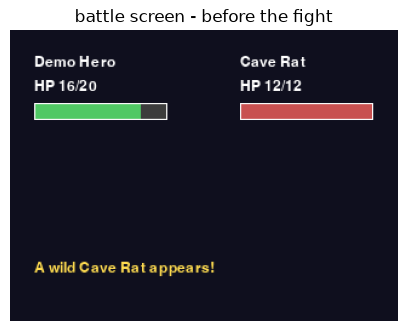

A battle begins: Demo Hero vs Cave Rat!
Demo Hero attacks Cave Rat for 8 damage! Cave Rat HP: 4/12
Cave Rat attacks Demo Hero for 1 damage! Demo Hero HP: 15/20
Demo Hero attacks Cave Rat for 6 damage! Cave Rat HP: 0/12
Cave Rat was defeated!
battle result: victory


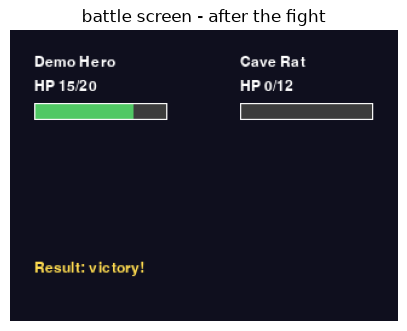

In [5]:
standalone_enemy = Enemy("Cave Rat", hp=12, attack=4, defense=1)

# a scripted sequence of player actions - just plain attacks this time, no items needed for such a weak enemy
standalone_actions = [("attack", None), ("attack", None), ("attack", None), ("attack", None)]

show_surface(draw_battle_screen(demo_hero, standalone_enemy, "A wild Cave Rat appears!"), title="battle screen - before the fight")

battle_log, battle_result = run_battle(demo_hero, standalone_enemy, standalone_actions)
for line in battle_log:  # print the turn-by-turn log, same "build a list, print it afterwards" idea as lesson 18
    print(line)
print("battle result:", battle_result)

show_surface(draw_battle_screen(demo_hero, standalone_enemy, f"Result: {battle_result}!"), title="battle screen - after the fight")

## rebuilding a tiny world + NPC (recap lesson 31's ideas)
* lesson 31 built a full tile-grid world with a player, NPCs and a dialogue overlay - this notebook is self-contained, so we rebuild a SMALL version of that same idea ourselves, from scratch, just enough to stage our playthrough
* `#` is a wall tile, `.` is open floor - `Player.try_move()` (defined above) already checks both wall collision AND collision against a "blocked position" like an NPC's tile
* the dialogue box is the same idea as lesson 31: a small rectangle drawn on top of the world, with `pygame.font` text blitted onto it

In [6]:
TILE_SIZE = 32  # each grid tile is 32x32 pixels

# our tiny world - 10 columns x 6 rows, walls around the border plus one inner wall block to demonstrate collision
WORLD_MAP = [
    "##########",
    "#........#",
    "#..####..#",
    "#..####..#",
    "#........#",
    "##########",
]


class NPC:
    """A non-player character standing at a fixed grid position, with a short list of dialogue lines."""

    def __init__(self, x: int, y: int, name: str, lines: list):
        self.x = x
        self.y = y
        self.name = name
        self.lines = lines  # a list of strings - in a bigger game this might advance one line per interaction


def draw_world(world_map, player: Player, npc: NPC, enemy_pos):
    """Draw the whole grid, the NPC, the enemy (if it's still around) and the player, in that back-to-front order."""
    screen.fill((10, 10, 15))
    for row_index, row in enumerate(world_map):
        for col_index, tile_char in enumerate(row):
            tile_rect = (col_index * TILE_SIZE, row_index * TILE_SIZE, TILE_SIZE, TILE_SIZE)
            tile_color = (70, 70, 85) if tile_char == "#" else (40, 110, 60)  # grey walls, green floor
            pygame.draw.rect(screen, tile_color, tile_rect)
            pygame.draw.rect(screen, (20, 20, 25), tile_rect, 1)  # thin grid lines so individual tiles are visible

    # the NPC - a yellow square, drawn a little smaller than the tile so it doesnt touch the grid lines
    pygame.draw.rect(screen, (220, 200, 60), (npc.x * TILE_SIZE + 4, npc.y * TILE_SIZE + 4, TILE_SIZE - 8, TILE_SIZE - 8))

    # the enemy - only drawn while it's still alive/on the map, it vanishes once defeated
    if enemy_pos is not None:
        pygame.draw.rect(screen, (200, 60, 60), (enemy_pos[0] * TILE_SIZE + 4, enemy_pos[1] * TILE_SIZE + 4, TILE_SIZE - 8, TILE_SIZE - 8))

    # the player - drawn LAST so it's always visible on top of everything else
    pygame.draw.rect(screen, (60, 140, 230), (player.x * TILE_SIZE + 4, player.y * TILE_SIZE + 4, TILE_SIZE - 8, TILE_SIZE - 8))
    return screen


def draw_dialogue_box(surface, speaker: str, text: str):
    """Draw a small text-box overlay on top of whatever is already on the surface (recap lesson 31)."""
    box_rect = pygame.Rect(10, 188, 300, 46)
    pygame.draw.rect(surface, (20, 20, 20), box_rect)         # solid dark background so the text is readable
    pygame.draw.rect(surface, (255, 255, 255), box_rect, 2)    # a white outline to frame the box
    surface.blit(font.render(f"{speaker}:", True, (255, 220, 80)), (box_rect.x + 8, box_rect.y + 6))
    surface.blit(font.render(text, True, (255, 255, 255)), (box_rect.x + 8, box_rect.y + 24))
    return surface


print("world map ready:", len(WORLD_MAP), "rows x", len(WORLD_MAP[0]), "columns")

world map ready: 6 rows x 10 columns


## putting it all together: a short, complete, scripted RPG playthrough
* now lets play through a tiny but COMPLETE RPG story beat by beat, entirely driven by a hardcoded script (never a loop waiting for real input):
  1. the player explores the world and bumps into a wall AND into the NPC (both blocked by `try_move()`'s collision checks)
  2. the player talks to the NPC, who warns about a goblin and hands over a weapon
  3. the player walks toward the goblin's location and the encounter triggers automatically
  4. the turn-based battle plays out (using an item mid-fight!) and the player wins
  5. we compare hp/inventory before and after, and see the goblin gone from the world afterwards
* we grab a snapshot at every one of those beats and show them all together at the end, like a little comic strip of the whole adventure

starting stats: Hero (HP 22/22, ATK 5, DEF 2)
starting inventory: ['Minor Potion']


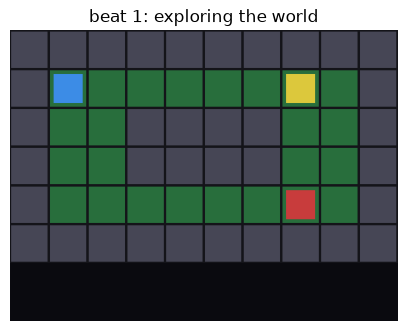

In [7]:
# --- step 1: set the story up ---------------------------------------------------------------------------------
NPC_POS = (7, 1)     # the village elder's fixed spot
ENEMY_START_POS = (7, 4)  # where the goblin is lurking

elder = NPC(*NPC_POS, "Elder Rowan", [
    "Careful traveler, a goblin has been terrorizing the eastern chamber!",
    "Here, take this old sword - it should help you in the fight.",
])

hero = Player("Hero", x=1, y=1, hp=22, attack=5, defense=2)   # our real playthrough hero, starts near the entrance
hero.inventory.add_item(Item(name="Minor Potion", item_type="potion", heal_amount=8))  # sets off with one potion

goblin = Enemy("Goblin", hp=16, attack=4, defense=1)  # the enemy waiting at ENEMY_START_POS
enemy_alive = True  # tracks whether the goblin is still standing on the map (drawn) or defeated (removed)

snapshots = []  # (label, pixel_array) tuples, one per story beat, shown together at the very end

print("starting stats:", hero)
print("starting inventory:", hero.inventory.list_item_names())

surface = draw_world(WORLD_MAP, hero, elder, ENEMY_START_POS)
snapshots.append(("1. exploring the world", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 1: exploring the world")

In [8]:
# --- step 2: walk towards the elder, demonstrating both kinds of collision along the way -----------------------
# a scripted list of (label, dx, dy) moves - never real keyboard input, we already know the whole route
moves_to_npc = [
    ("bump into the border wall on purpose", 0, -1),   # (1,1) -> (1,0) is a wall, should be BLOCKED
    ("down", 0, 1), ("down", 0, 1), ("down", 0, 1),      # (1,1) -> (1,4)
    ("right", 1, 0), ("right", 1, 0), ("right", 1, 0), ("right", 1, 0),
    ("right", 1, 0), ("right", 1, 0), ("right", 1, 0),   # (1,4) -> (8,4)
    ("up", 0, -1), ("up", 0, -1), ("up", 0, -1),         # (8,4) -> (8,1)
    ("bump into the NPC on purpose", -1, 0),              # (8,1) -> (7,1) is the elder's own tile, should be BLOCKED
]

for label, dx, dy in moves_to_npc:
    moved = hero.try_move(dx, dy, WORLD_MAP, blocked_positions={NPC_POS})
    print(f"{label}: {'moved to ' + str((hero.x, hero.y)) if moved else 'blocked!'}")

# the hero is now standing right next to the elder (adjacent tiles, distance 1) - close enough to talk
distance_to_npc = abs(hero.x - elder.x) + abs(hero.y - elder.y)
print("distance to the elder:", distance_to_npc, "(1 means standing right next to them)")

bump into the border wall on purpose: blocked!
down: moved to (1, 2)
down: moved to (1, 3)
down: moved to (1, 4)
right: moved to (2, 4)
right: moved to (3, 4)
right: moved to (4, 4)
right: moved to (5, 4)
right: moved to (6, 4)
right: moved to (7, 4)
right: moved to (8, 4)
up: moved to (8, 3)
up: moved to (8, 2)
up: moved to (8, 1)
bump into the NPC on purpose: blocked!
distance to the elder: 1 (1 means standing right next to them)


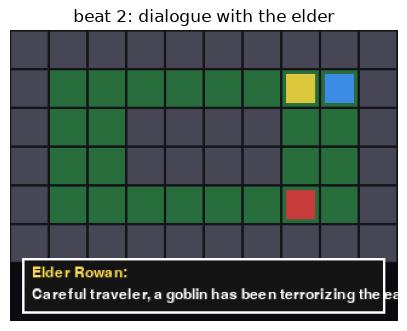

Elder Rowan: Careful traveler, a goblin has been terrorizing the eastern chamber!
Elder Rowan: Here, take this old sword - it should help you in the fight.
Hero received Old Sword!
Hero equips Old Sword! attack is now 8
inventory now: ['Minor Potion', 'Old Sword']


In [9]:
# --- step 3: talk to the elder - a scripted dialogue, then receive an item ---------------------------------
surface = draw_world(WORLD_MAP, hero, elder, ENEMY_START_POS)
draw_dialogue_box(surface, elder.name, elder.lines[0])  # the warning about the goblin
snapshots.append(("2. talking to the elder", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 2: dialogue with the elder")

print(f"{elder.name}: {elder.lines[0]}")
print(f"{elder.name}: {elder.lines[1]}")

old_sword = Item(name="Old Sword", item_type="weapon", attack_bonus=3)
print(hero.inventory.add_item(old_sword))      # the elder hands it over
print(hero.inventory.use_item(old_sword))      # the hero equips it right away - permanent attack boost
print("inventory now:", hero.inventory.list_item_names())

In [10]:
# --- step 4: walk towards the goblin, the encounter triggers automatically on arrival -----------------------
moves_to_enemy = [
    ("down", 0, 1), ("down", 0, 1), ("down", 0, 1),  # (8,1) -> (8,4)
    ("left", -1, 0),                                    # (8,4) -> (7,4), exactly the goblin's tile - encounter!
]

for label, dx, dy in moves_to_enemy:
    moved = hero.try_move(dx, dy, WORLD_MAP)
    print(f"{label}: {'moved to ' + str((hero.x, hero.y)) if moved else 'blocked!'}")

encountered = (hero.x, hero.y) == ENEMY_START_POS
print("stepped onto the goblin's tile, battle incoming?", encountered)

down: moved to (8, 2)
down: moved to (8, 3)
down: moved to (8, 4)
left: moved to (7, 4)
stepped onto the goblin's tile, battle incoming? True


before the battle: Hero (HP 22/22, ATK 8, DEF 2)
before the battle inventory: ['Minor Potion', 'Old Sword']


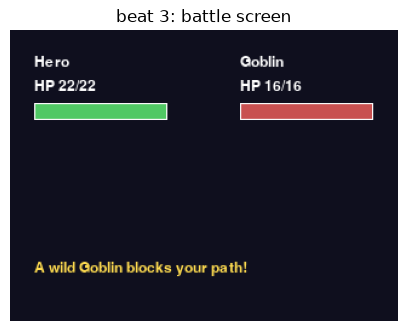

A battle begins: Hero vs Goblin!
Hero attacks Goblin for 8 damage! Goblin HP: 8/16
Goblin attacks Hero for 2 damage! Hero HP: 20/22
Hero attacks Goblin for 6 damage! Goblin HP: 2/16
Goblin attacks Hero for 1 damage! Hero HP: 19/22
Hero drinks Minor Potion and heals 3 HP! HP: 22/22
Goblin attacks Hero for 1 damage! Hero HP: 21/22
Hero attacks Goblin for 8 damage! Goblin HP: 0/16
Goblin was defeated!
battle result: victory


In [11]:
# --- step 5: the battle! -----------------------------------------------------------------------------------
print("before the battle:", hero)
print("before the battle inventory:", hero.inventory.list_item_names())

# a scripted plan: attack twice, heal up with the potion once things get rough, then finish the job
playthrough_actions = [
    ("attack", None),
    ("attack", None),
    ("item", hero.inventory.items[0] if hero.inventory.items else None),  # use whatever potion is still in the bag
    ("attack", None),
    ("attack", None),
]

surface = draw_battle_screen(hero, goblin, "A wild Goblin blocks your path!")
snapshots.append(("3. battle screen", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 3: battle screen")

battle_log, battle_result = run_battle(hero, goblin, playthrough_actions)
for line in battle_log:
    print(line)
print("battle result:", battle_result)

if battle_result == "victory":
    enemy_alive = False  # the goblin is defeated, it will no longer be drawn on the world map

after the battle: Hero (HP 21/22, ATK 8, DEF 2)
after the battle inventory: ['Old Sword']


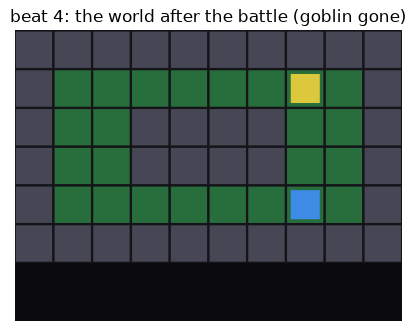

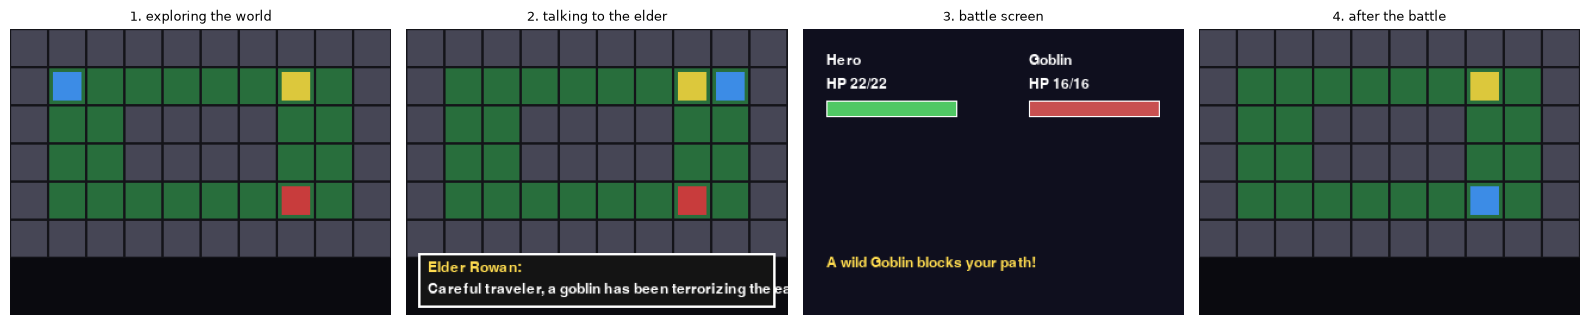


and that's a complete (tiny!) RPG playthrough: explore -> talk -> get an item -> fight -> win


In [12]:
# --- step 6: aftermath - compare before/after, and show the world with the goblin gone ------------------------
print("after the battle:", hero)
print("after the battle inventory:", hero.inventory.list_item_names())  # the potion is gone, the sword stayed

surface = draw_world(WORLD_MAP, hero, elder, None if not enemy_alive else ENEMY_START_POS)
snapshots.append(("4. after the battle", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 4: the world after the battle (goblin gone)")

# and finally, our little "comic strip" of the whole adventure, all 4 beats side by side
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5))
for ax, (label, pixels) in zip(axes, snapshots):
    ax.imshow(pixels)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

print()
print("and that's a complete (tiny!) RPG playthrough: explore -> talk -> get an item -> fight -> win")

## Ideas to extend this RPG further
* the game-dev arc ends here, but this little RPG absolutely doesnt have to - here are a few open-ended ideas to keep building on your own, no solutions provided this time!
* add multiple enemy TYPES with different stats (a fast-but-weak bat, a slow-but-tough troll, ...) and maybe pick which one to spawn randomly
* add a proper equipment SYSTEM: instead of `use_item()` instantly and permanently boosting attack, track a separate "currently equipped weapon" slot, so a player could swap weapons later, or even unequip one
* add a simple quest-tracking flag system - a `dict` (or a `@dataclass`) of booleans like `{"warned_about_goblin": True, "goblin_defeated": True}`, and have an NPC's dialogue line CHANGE depending on which flags are set
* add a save/load system, using `sqlite3` (lesson 13) or plain `json` (lesson 05) to persist the player's hp, inventory and grid position between runs, so a playthrough could be paused and resumed later
* add real sound effects for hits, item pickups and victories using `pygame.mixer` (recap lesson 27) - this notebook only has the dummy audio driver, so real usage would need actual `.wav`/`.ogg` files and a real sound card, but the `mixer.Sound(...).play()` API itself is exactly the same
* add a proper title screen / game-over screen STATE MACHINE - an enum (recap lesson 10) of game states like `TITLE`, `PLAYING`, `BATTLE`, `GAME_OVER`, and a main loop that draws/updates differently depending on which state its currently in

* congratulation, you finished the whole game development arc!

## what we learned in this capstone
* an `Item` `@dataclass` and an `Inventory` class, with `add_item()`/`use_item()` telling consumable potions (removed after use) apart from permanent weapon equips (kept forever)
* a `Character` base class shared by `Player` and `Enemy` (recap inheritance), with an `is_alive` property instead of a manually tracked flag
* a full turn-based battle system: a damage formula with a small, reproducible random swing, alternating player/enemy turns, a readable turn-by-turn battle log, and a simple hp-bar battle screen
* rebuilt a tiny version of lesson 31's world/player/NPC/dialogue setup entirely from scratch, self-contained in this one notebook
* tied everything together into one short but COMPLETE scripted playthrough: explore -> talk -> receive an item -> encounter an enemy -> fight -> win -> see the aftermath

## what we learned across the whole game-dev arc
* 27: pygame fundamentals - the headless dummy-driver trick, drawing primitives, the game loop, simulated input, `Rect` collision and sound
* 28: building classic mini-games on top of those fundamentals
* 29: sprites, animation and tilemaps for more visually rich games
* 30: generating procedural graphics entirely in code
* 31: a small RPG's world map, grid-based player movement, NPCs and a dialogue overlay
* 32 (this one!): inventory, turn-based battles, and tying the whole RPG together into one complete playable demo

thank you for following along through this entire game development arc - now go build a game of your own with it!